要运行此程序，请在 **AMD Dev Cloud** 上按“*运行*”并按“*运行全部*”！
<div class="align-center">
<a href="https://unsloth.ai/"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
<a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord button.png" width="145"></a>
<a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a> 如果您需要帮助，请加入 Discord + ⭐ <i>在 <a href="https://github.com/unslothai/unsloth">Github</a> 上为我们加注星标</a> </i> ⭐
</div>

要在本地设备上安装 Unsloth，请按照 [our guide](https://unsloth.ai/docs/get-started/install) 操作。此笔记本已获得许可 [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme)。

您将学习如何执行 [data prep](#Data)、如何执行 [train](#Train)、如何执行 [run the model](#Inference) 以及如何保存它

### 消息

隆重推出 **Unsloth Studio** - 一个新的开源、无代码 Web UI，用于训练和运行法学硕士。 [Blog](https://unsloth.ai/docs/new/studio) • [Notebook](https://colab.research.google.com/github/unslothai/unsloth/blob/main/studio/Unsloth_Studio_Colab.ipynb)

<表><tr>
<tdalign="center"><a href="https://unsloth.ai/docs/new/studio"><img src="https://unsloth.ai/docs/~gitbook/image?url=https%3A%2F%2F3215535692-files.gitbook.io%2F~% 2Ffiles%2Fv0%2Fb%2Fgitbook-x-prod.appspot.com%2Fo%2Fspaces%252FxhOjnexMCB3dmuQFQ2Zq%252Fupload s%252FxV1PO5DbF3ksB51nE2Tw%252Fmore%2520cropped%2520ui%2520for%2520homepage.png%3Falt%3Dmedia% 26token%3Df75942c9-3d8d-4b59-8ba2-1a4a38de1b86&宽度=376&dpr=3&质量=100&sign=a663c397&sv=2" width="200" height="120" alt="Unsloth Studio Training UI"></a><br><sub><b>训练模型</b> - 无需代码</sub></td>
<tdalign="center"><a href="https://unsloth.ai/docs/new/studio"><img src="https://unsloth.ai/docs/~gitbook/image?url=https%3A%2F%2F3215535692-files.gitbook.io%2F~%2Ffiles%2Fv0%2Fb%2Fgitbook-x-prod.appspot.com%2Fo%2Fspaces%252FxhOjnexMCB3dmuQFQ2Z q%252Fuploads%252FRCnTAZ6Uh88DIlU3g0Ij%252Fmainpage%2520unsloth.png%3Falt%3Dmedia%26toke n%3D837c96b6-bd09-4e81-bc76-fa50421e9bfb&宽度=376&dpr=3&质量=100&sign=c1a39da1&sv=2" width="200" height="120" alt="Unsloth Studio 聊天 UI"></a><br><sub><b>在 Mac、Windows 和 Linux 上运行 GGUF 模型</b></sub></td>
</tr></表>

训练 MoE - DeepSeek、GLM、Qwen 和 gpt-oss 速度提高 12 倍，VRAM 减少 35%。 [Blog](https://unsloth.ai/docs/new/faster-moe)

超长上下文强化学习现已推出，上下文窗口增加了 7 倍！ [Blog](https://unsloth.ai/docs/new/grpo-long-context)

强化学习新功能：[FP8 RL](https://unsloth.ai/docs/new/fp8-reinforcement-learning) • [Vision RL](https://unsloth.ai/docs/new/vision-reinforcement-learning-vlm-rl) • [Standby](https://unsloth.ai/docs/basics/memory-efficient-rl) • [gpt-oss RL](https://unsloth.ai/docs/new/gpt-oss-reinforcement-learning)

请访问我们的文档以获取所有 [model uploads](https://unsloth.ai/docs/get-started/unsloth-model-catalog) 和 [notebooks](https://unsloth.ai/docs/get-started/unsloth-notebooks)。

### 安装

In [ ]:
%%bash
python -m pip install -qU uv --root-user-action=ignore

ROCM_TAG="$({ command -v amd-smi >/dev/null 2>&1 && amd-smi version 2>/dev/null | awk -F'ROCm version: ' 'NF>1{split($2,a,"."); print "rocm"a[1]"."a[2]; ok=1; exit} END{exit !ok}'; } || { [ -r /opt/rocm/.info/version ] && awk -F. '{print "rocm"$1"."$2; exit}' /opt/rocm/.info/version; } || { command -v hipconfig >/dev/null 2>&1 && hipconfig --version 2>/dev/null | awk -F': *' '/HIP version/{split($2,a,"."); print "rocm"a[1]"."a[2]; ok=1; exit} END{exit !ok}'; } || { command -v dpkg-query >/dev/null 2>&1 && ver="$(dpkg-query -W -f='${Version}\n' rocm-core 2>/dev/null)" && [ -n "$ver" ] && awk -F'[.-]' '{print "rocm"$1"."$2; exit}' <<<"$ver"; } || { command -v rpm >/dev/null 2>&1 && ver="$(rpm -q --qf '%{VERSION}\n' rocm-core 2>/dev/null)" && [ -n "$ver" ] && awk -F'[.-]' '{print "rocm"$1"."$2; exit}' <<<"$ver"; })"
[ -n "$ROCM_TAG" ] || { echo "Could not detect ROCm. Install ROCm first or set ROCM_TAG manually."; exit 1; }
case "$ROCM_TAG" in
  rocm6.[0-4]|rocm7.[02]) T="$ROCM_TAG" ;;
  rocm6.*) T="rocm6.4" ;;
  *) T="rocm7.1" ;;
esac
pip install bitsandbytes
PYTORCH_INDEX_URL="https://download.pytorch.org/whl/${T}"
uv pip install --system -U --force-reinstall \
    torch torchvision torchaudio triton-rocm \
    --index-url "$PYTORCH_INDEX_URL"
uv pip install --system cut-cross-entropy torchao --no-deps
uv pip install --system -U --no-deps "unsloth[amd]" "unsloth_zoo[amd]"
uv pip install --system --no-deps -r "$(python -c 'import pathlib,site;print(next(p for r in [*site.getsitepackages(),site.getusersitepackages()] if (p:=pathlib.Path(r,"studio/backend/requirements/no-torch-runtime.txt")).exists()))')" torchao
uv pip install --system --no-deps -U "tokenizers>=0.22.0,<=0.23.0"


In [ ]:
# Gemma 4 需要变形金刚 >= 5.5.0 / trl >= 0.28.0

import torch; torch._dynamo.config.recompile_limit = 64;
!uv pip install --system -qqq --upgrade --no-deps "transformers>=5.10.1" "huggingface_hub>=1.5.0" "datasets==4.3.0" accelerate peft sentencepiece protobuf hf_transfer "trl>=0.28.0" timm
!uv pip install --system -qqq torchcodec


### 不懒惰

In [ ]:
from unsloth import FastVisionModel
import torch

gemma4_models = [
    # Gemma-4 指令模型：
    "unsloth/gemma-4-E2B-it",
    "unsloth/gemma-4-E4B-it",
    "unsloth/gemma-4-31B-it",
    "unsloth/gemma-4-26B-A4B-it",
    # Gemma-4 基本型号：
    "unsloth/gemma-4-E2B",
    "unsloth/gemma-4-E4B",
    "unsloth/gemma-4-31B",
    "unsloth/gemma-4-26B-A4B",
] # 更多模型请访问 https://huggingface.co/unsloth

model, processor = FastVisionModel.from_pretrained(
    "unsloth/gemma-4-12b-it",
    load_in_4bit = False, # 使用4bit来减少内存使用。对于 16 位 LoRA 为假。
    use_gradient_checkpointing = "unsloth", # 长上下文中的真实或“不懒惰”
)

==((====))==  Unsloth 2026.5.10: Fast Gemma4_Unified patching. Transformers: 5.10.0.dev0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


model.safetensors:   0%|          | 0.00/23.9G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/677 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/260 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/1.38k [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/17.5k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/20.6k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

我们现在添加 LoRA 适配器来进行参数高效微调，使我们能够高效训练所有模型参数的 1%。

**[新]** 我们还支持仅微调视觉组件、仅微调语言组件或两者。此外，您可以选择微调注意力模块、MLP 层或两者！

In [5]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # 如果不微调视觉层则为假
    finetune_language_layers   = True, # 如果不微调语言层则为 False
    finetune_attention_modules = True, # 如果不微调注意力层则为假
    finetune_mlp_modules       = True, # 如果不微调 MLP 层则为 False

    r = 32,                           # 越大，准确率越高，但可能会过拟合
    lora_alpha = 32,                  # 建议 alpha == r 至少
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,               # 我们支持排名稳定的 LoRA
    loftq_config = None,               # 和阁楼Q
    target_modules = "all-linear",    # 现在可选！如果需要可以指定列表
)

<a名称=“数据”></a>
### 数据准备
我们将使用手写数学公式的采样数据集。目标是将这些图像转换为计算机可读的格式（特别是 LaTeX），以便可以渲染它们。这对于复杂的表达式特别有用。

您可以访问数据集[here](https://huggingface.co/datasets/unsloth/LaTeX_OCR)。完整数据集是[here](https://huggingface.co/datasets/linxy/LaTeX_OCR)。

In [6]:
from datasets import load_dataset
dataset = load_dataset("unsloth/LaTeX_OCR", split = "train")

README.md:   0%|          | 0.00/519 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/344M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/38.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/68686 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7632 [00:00<?, ? examples/s]

让我们概述一下数据集。我们将检查第二张图像及其相应的标题。

In [7]:
dataset

Dataset({
    features: ['image', 'text'],
    num_rows: 68686
})

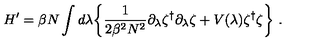

In [8]:
dataset[2]["image"]

In [9]:
dataset[2]["text"]

'H ^ { \\prime } = \\beta N \\int d \\lambda \\biggl \\{ \\frac { 1 } { 2 \\beta ^ { 2 } N ^ { 2 } } \\partial _ { \\lambda } \\zeta ^ { \\dagger } \\partial _ { \\lambda } \\zeta + V ( \\lambda ) \\zeta ^ { \\dagger } \\zeta \\biggr \\} \\ .'

我们还可以直接在浏览器中渲染LaTeX！

In [10]:
from IPython.display import display, Math, Latex

latex = dataset[3]["text"]
display(Math(latex))

<IPython.core.display.Math object>

要格式化数据集，所有视觉微调任务都应遵循以下格式：

```python
[
    {
        "role": "user",
        "content": [
            {"type": "text", "text": instruction},
            {"type": "image", "image": sample["image"]},
        ],
    },
    {
        "role": "user",
        "content": [
            {"type": "text", "text": instruction},
            {"type": "image", "image": sample["image"]},
        ],
    },
]
```

In [11]:
instruction = "Write the LaTeX representation for this image."

def convert_to_conversation(sample):
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": instruction},
                {"type": "image", "image": sample["image"]},
            ],
        },
        {"role": "assistant", "content": [{"type": "text", "text": sample["text"]}]},
    ]
    return {"messages": conversation}
pass

让我们将数据集转换为“正确”的格式以进行微调：

In [12]:
converted_dataset = [convert_to_conversation(sample) for sample in dataset]

第一个示例现在的结构如下：

In [13]:
converted_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Write the LaTeX representation for this image.'},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=160x40>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': '{ \\frac { N } { M } } \\in { \\bf Z } , { \\frac { M } { P } } \\in { \\bf Z } , { \\frac { P } { Q } } \\in { \\bf Z }'}]}]}

让我们采用 Gemma 4 指令聊天模板并在我们的基本模型中使用它

In [14]:
from unsloth import get_chat_template

processor = get_chat_template(
    processor,
    "gemma-4"
)

在微调之前，让我们评估基本模型的性能。我们预计不会有很强的结果，因为它以前没有遇到过这个聊天模板。

In [15]:
image = dataset[2]["image"]
instruction = "Write the LaTeX representation for this image."

messages = [
    {
        "role": "user",
        "content": [{"type": "image"}, {"type": "text", "text": instruction}],
    }
]
input_text = processor.apply_chat_template(messages, add_generation_prompt = True)
inputs = processor(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer

text_streamer = TextStreamer(processor, skip_prompt = True)
result = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                        use_cache = False, temperature = 1.0, top_p = 0.95, top_k = 64)

<|channel>thought
<channel|>To represent the mathematical expression in the image using LaTeX, you can use. following code:

```latex
H' = \beta N \int d\lambda \left\{ \frac{1}{2\beta^20 N^2} \partial_\lambda \zeta^\dagger \partial_\lambda \zeta + V(\lambda) \zeta^\dagger \zeta \right/
```

**Note:** There appears to be a slight inconsistency in the image where the fraction $\frac{1}{2\beta^2 N^}$ is written twice in different forms (once as $\frac{1


你可以看到这绝对是可怕的！它根本不遵循说明

<a name="火车"></a>
### 训练模型
现在让我们训练我们的模型。我们执行 60 个步骤来加快速度，但您可以设置“num_train_epochs=1”以进行完整运行，并关闭“max_steps=None”。我们还支持`DPOTrainer`和`GRPOTrainer`用于强化学习！

我们使用新的“UnslothVisionDataCollat​​or”，这将有助于我们的视觉微调设置。

In [16]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model = model,
    train_dataset = converted_dataset,
    processing_class = processor.tokenizer,
    data_collator = UnslothVisionDataCollator(model, processor),
    args = SFTConfig(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 4,
        max_grad_norm = 0.3,
        warmup_ratio = 0.03,
        max_steps = 60,
        # num_train_epochs = 2, # 设置此值而不是 max_steps 以进行完整的训练运行
        learning_rate = 2e-4,
        logging_steps = 1,
        save_strategy = "steps",
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none", # 对于权重和偏差或其他

        # 您必须放置以下项目进行视力微调：
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    )
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Model does not have a default image size - using 512


In [17]:
# @title 显示当前内存统计信息
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA A100-SXM4-40GB. Max memory = 39.494 GB.
22.895 GB of memory reserved.


In [18]:
trainer_stats = trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 68,686 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 131,137,536 of 12,090,867,712 (1.08% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
1,3.105556
2,3.877516
3,3.243568
4,3.304965
5,2.580325
6,2.338940
7,1.456435
8,1.392660
9,1.548063
10,0.757146


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-60/tokenizer_config.json.


In [19]:
# @title 显示最终内存和时间统计数据
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

230.7141 seconds used for training.
3.85 minutes used for training.
Peak reserved memory = 24.203 GB.
Peak reserved memory for training = 1.308 GB.
Peak reserved memory % of max memory = 61.283 %.
Peak reserved memory for training % of max memory = 3.312 %.


<a name="推理"></a>
### 推论
让我们运行模型吧！您可以修改指令和输入，只需将输出留空即可。

我们将使用最佳超参数在 Gemma 上进行推理：“top_p=0​​.95”、“top_k=64”和“温度=1.0”。

In [20]:
image = dataset[10]["image"]
instruction = "Write the LaTeX representation for this image."

messages = [
    {
        "role": "user",
        "content": [{"type": "image"}, {"type": "text", "text": instruction}],
    }
]

input_text = processor.apply_chat_template(messages, add_generation_prompt = True)

inputs = processor(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer

text_streamer = TextStreamer(processor, skip_prompt = True)
result = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                        use_cache = False, temperature = 1.0, top_p = 0.95, top_k = 64)

[ [ B B _ { n } ^ { + } , b _ { 2 } ^ { - } ] , b _ { 2 } ^ { + }. ] = n B _ { n } ^ { + } , \quad [ [ B _ { n } ^ { - } , b _ { _ { 2 } ^ { + } } ] , b _ { 2 } ^ { - } ] = n B _ { n } ^ { - } .<turn|>


<a name="保存"></a>
### 保存、加载微调模型
要将最终模型保存为 LoRA 适配器，请使用 Hugging Face 的 `push_to_hub` 进行在线保存，或使用 `save_pretrained` 进行本地存储。

**[注意]** 这仅保存 LoRA 适配器，而不是完整模型。要保存到 16 位或 GGUF，请向下滚动！

In [21]:
model.save_pretrained("gemma_4_lora")  # 本地储蓄
processor.save_pretrained("gemma_4_lora")
# model.push_to_hub("your_name/gemma_4_lora", token = "YOUR_HF_TOKEN") # 在线保存
# handler.push_to_hub("your_name/gemma_4_lora", token = "YOUR_HF_TOKEN") # 在线保存

Unsloth: Restored added_tokens_decoder metadata in gemma_4_lora/tokenizer_config.json.


['gemma_4_lora/processor_config.json']

现在，如果您想加载我们刚刚保存用于推理的 LoRA 适配器，请将“False”设置为“True”：

In [22]:
if False:
    from unsloth import FastVisionModel

    model, processor = FastVisionModel.from_pretrained(
        model_name = "gemma_4_lora",  # 您用于训练的模型
        load_in_4bit = True,  # 对于 16 位 LoRA 设置为 False
    )

sample = dataset[1]
image = sample["image"].convert("RGB")
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": sample["text"],
            },
            {
                "type": "image",
            },
        ],
    },
]
input_text = processor.apply_chat_template(messages, add_generation_prompt = True)
inputs = processor(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer

text_streamer = TextStreamer(processor.tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = False, temperature = 1.0, top_p = 0.95, top_k = 64)

D _ { \mu } ^ { \alpha \beta } \bar { A } _ { \mu } ^ { \. \beta } = 0 ,<turn|>


### 保存为 VLLM 的 float16

我们还支持直接保存到`float16`。为 float16 选择“merged_16bit”。使用 `push_to_hub_merged` 上传到您的 Hugging Face 帐户！您可以前往 https://huggingface.co/settings/tokens 获取您的个人代币。有关更多部署选项，请参阅 [our docs](https://unsloth.ai/docs/basics/inference-and-deployment)。

In [23]:
# 仅选择 1 个进行保存！ （两者都不需要！）

# 本地保存为16位
if False: model.save_pretrained_merged("unsloth_finetune", processor,)

# 导出并保存到您的 Hugging Face 帐户
if False: model.push_to_hub_merged("YOUR_USERNAME/unsloth_finetune", processor, token = "YOUR_HF_TOKEN")

我们就完成了！如果您对 Unsloth 有任何疑问，我们有 [Discord](https://discord.gg/unsloth) 频道！如果您发现任何错误或想要随时更新最新的 LLM 内容，或需要帮助、加入项目等，请随时加入我们的 Discord！

其他一些资源：
1.训练自己的推理模型——Llama GRPO笔记本[Free Colab](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3.1_(8B)-GRPO.ipynb)
2. 将微调保存到Ollama。 [Free notebook](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3_(8B)-Ollama.ipynb)
3. Llama 3.2 视觉微调 - 射线照相用例。 [Free Colab](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3.2_(11B)-Vision.ipynb)
4. 请参阅我们的 [documentation](https://unsloth.ai/docs/get-started/unsloth-notebooks) 上的 DPO、ORPO、持续预训练、对话微调等笔记本！

<div class="align-center">
  <a href="https://unsloth.ai"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
  <a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord.png" width="145"></a>
  <a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a>

  如果您需要帮助，请加入 Discord + ⭐️ <i>在 <a href="https://github.com/unslothai/unsloth">Github</a> 上为我们加注星标</i> ⭐️
</div>

  此笔记本和所有 Unsloth 笔记本均已获得 [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme) 许可。